# Non - conformal meshing

In [1]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pxtal = mcgs(study='independent', input_dashboard='input_dashboard_for_testing_50x50_alg202.xls')
pxtal.simulate()
pxtal.detect_grains()
tslice = 10
pxtal.gs[tslice].char_morph_2d(char_gb=True)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_for_testing_50x50_alg202.xls
Algo_hops details
(('202.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 32
     Dimensionality: 2
    weighted (: ALG-202)
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
Monte-Carlo temporal step = 1
GS temporal slice 2 stored
Monte-Carlo temporal step = 3
GS temporal slice 4 stored
Monte-Carlo temporal step = 5
GS temporal slice 6 stored
Monte-Carlo temporal step = 7
GS temporal slice 8 stored
Monte-Carlo temporal step = 9
GS temporal slice 10 stored
Monte-Carlo temporal step = 11
GS temporal slice 12 stored
Monte-Carlo temporal step = 13
GS temporal slice 14 stored

In [3]:
from upxo.meshing.mesher_2d import mesh_mcgs2d

In [4]:
femesh = mesh_mcgs2d(getFEControlsFromUPXO=True,
                     getGridControlsFromUPXO=True,
                     meshInfo=pxtal.uimesh,
                     gridInfo=pxtal.uigrid,
                     gsInfo=dict(m=tslice),
                     lfi=pxtal.gs[tslice].lfi,  )

In [5]:
femesh.ABQ_NODES

array([[ 1.000e+00, -5.000e-01, -5.000e-01],
       [ 2.000e+00,  5.000e-01, -5.000e-01],
       [ 3.000e+00,  1.500e+00, -5.000e-01],
       ...,
       [ 2.702e+03,  4.850e+01,  5.050e+01],
       [ 2.703e+03,  4.950e+01,  5.050e+01],
       [ 2.704e+03,  5.050e+01,  5.050e+01]], shape=(2704, 3))

In [6]:
femesh.ABQ_ELEMENTS

array([[   1,    1,    2,   54,   53],
       [   2,   53,   54,  106,  105],
       [   3,  105,  106,  158,  157],
       ...,
       [2599, 2547, 2548, 2600, 2599],
       [2600, 2599, 2600, 2652, 2651],
       [2601, 2651, 2652, 2704, 2703]], shape=(2601, 5))

In [7]:
51*51

2601

In [8]:
femesh.export_abaqus_inp_file(folder="C:\\Development\\UPXO\\upxo_library\\data\\ABQInputFiles",
                        file="UPXO_ABQ_MESH.inp")



Number of elements, nodes: 2601, 2704
Element type: quad4
Temporal slice number of the mcgs: 10
Target FE software: Abaqus
..............
Number of grain element sets: 218
Numebr of materials: 218
..............
ABAQUS input file has been successfully written


-------------------------------------------


In [9]:
femesh.ABQ_ELEMENTS

array([[   1,    1,    2,   54,   53],
       [   2,   53,   54,  106,  105],
       [   3,  105,  106,  158,  157],
       ...,
       [2599, 2547, 2548, 2600, 2599],
       [2600, 2599, 2600, 2652, 2651],
       [2601, 2651, 2652, 2704, 2703]], shape=(2601, 5))

In [10]:
femesh.ABQ_NODES

array([[ 1.000e+00, -5.000e-01, -5.000e-01],
       [ 2.000e+00,  5.000e-01, -5.000e-01],
       [ 3.000e+00,  1.500e+00, -5.000e-01],
       ...,
       [ 2.702e+03,  4.850e+01,  5.050e+01],
       [ 2.703e+03,  4.950e+01,  5.050e+01],
       [ 2.704e+03,  5.050e+01,  5.050e+01]], shape=(2704, 3))

(np.float64(-0.5), np.float64(50.5), np.float64(50.5), np.float64(-0.5))

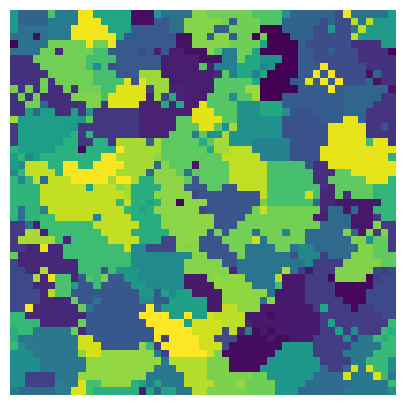

In [11]:
plt.figure(figsize=(10,5), dpi=100)
plt.imshow(pxtal.gs[tslice].lgi)
plt.axis('off')

In [12]:
np.random.random(10)

array([0.75624863, 0.53435354, 0.40957104, 0.68211527, 0.02264578,
       0.10701746, 0.85348751, 0.18498898, 0.3633028 , 0.37652254])

In [13]:
import os
os.cpu_count()

22

In [14]:
pxtal.ygr

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 2.,  2.,  2., ...,  2.,  2.,  2.],
       ...,
       [48., 48., 48., ..., 48., 48., 48.],
       [49., 49., 49., ..., 49., 49., 49.],
       [50., 50., 50., ..., 50., 50., 50.]], shape=(51, 51))